# 25 — Assembly101 Qwen Pseudo-Text Teacher Validation

This notebook evaluates whether inference-time pseudo-text generated by
Qwen3.5 helps the frozen privileged teacher from notebook 18.

The teacher weights, video normalization, temporal architecture, class
mapping, and validation split are not retrained or reselected. Only the
text input changes:

1. ground-truth text — oracle upper bound;
2. Qwen3.5 pseudo-text — proposed inference-time pipeline;
3. temporally shuffled Qwen text — alignment sanity control;
4. zero text — missing-text control.

The original visual-only MS-TCN validation result is loaded as an external
reference. The primary metric is **F1@50**, following the supervisor's
feedback. This notebook reads validation labels for evaluation, but does
not access test features, test labels, or test pseudo-text.


## Fixed evaluation protocol

| Component | Choice |
|---|---|
| Dataset | Assembly101 official validation split, 120 sequences |
| Video features | CLIP ViT-B/16 `[512, 16]` |
| Teacher | frozen notebook-18 MS-TCN concatenation teacher |
| Teacher checkpoint | epoch 120, selected before this experiment |
| Pseudo-text | notebook-24 Qwen3.5-2B closed-set output `[512, 16]` |
| Zero fallback | 16 positions from one failed VLM sequence |
| Primary metric | F1@50 |
| Test access | none |

The Qwen prompt was frozen before validation metrics were computed. The
strict go/no-go criterion for generating test pseudo-text is that Qwen
must beat both text controls on validation F1@50 and must not underperform
the original visual-only MS-TCN validation F1@50.


## 1. Mount Google Drive


In [2]:
from google.colab import drive
drive.mount("/content/drive", force_remount=True)


Mounted at /content/drive


## 2. Imports, reproducibility, and hardware


In [3]:
from pathlib import Path
from datetime import datetime, timezone

import gc
import hashlib
import json
import math
import os
import platform
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

pd.set_option("display.max_columns", 180)
pd.set_option("display.max_colwidth", 260)

SEED = 7

def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_global_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


Python: 3.12.13
PyTorch: 2.11.0+cu128
Device: cuda
GPU: Tesla T4


## 3. Paths and locked configuration


In [4]:
DRIVE_ROOT = Path("/content/drive/MyDrive/mmf_tas_lab_data")
FEATURE_ROOT = (
    DRIVE_ROOT
    / "text_assisted_tas"
    / "assembly101"
    / "coarse_mstcn_format"
    / "streaming_visual_features_v1"
)
CLIP_DATA_ROOT = FEATURE_ROOT / "clip_vitb16"

FEATURE_DIR = CLIP_DATA_ROOT / "features"
GT_DIR = CLIP_DATA_ROOT / "groundTruth"
SPLIT_DIR = CLIP_DATA_ROOT / "splits"
MAPPING_PATH = CLIP_DATA_ROOT / "mapping.txt"

TEXT_EMBEDDING_PATH = (
    CLIP_DATA_ROOT
    / "text_embeddings"
    / "assembly101_coarse_clip_vitb16_text_embeddings.npy"
)
TEXT_METADATA_PATH = (
    CLIP_DATA_ROOT
    / "text_embeddings"
    / "assembly101_coarse_clip_vitb16_text_metadata.csv"
)

NOTEBOOK18_ROOT = (
    FEATURE_ROOT / "runs" / "18_text_assisted_concat_teachers"
)
NOTEBOOK18_SUMMARY = NOTEBOOK18_ROOT / "final_summary_full.json"
TEACHER_EXPERIMENT_ROOT = (
    NOTEBOOK18_ROOT / "mstcn" / "clip_vitb16" / "full"
)
TEACHER_CHECKPOINT = (
    TEACHER_EXPERIMENT_ROOT / "models" / "best_teacher.pt"
)
TRAIN_VIDEO_MEAN_PATH = (
    TEACHER_EXPERIMENT_ROOT / "results" / "train_video_mean.npy"
)
TRAIN_VIDEO_STD_PATH = (
    TEACHER_EXPERIMENT_ROOT / "results" / "train_video_std.npy"
)

NOTEBOOK24_ROOT = (
    FEATURE_ROOT
    / "runs"
    / "24_qwen35_pseudotext"
    / "qwen35_2b_closedset_temporal_v1"
)
NOTEBOOK24_SUMMARY = NOTEBOOK24_ROOT / "final_summary.json"
PSEUDOTEXT_DIR = NOTEBOOK24_ROOT / "pseudotext_embeddings"
PARSED_PREDICTION_DIR = NOTEBOOK24_ROOT / "parsed_predictions"

VISUAL_BASELINE_SUMMARY = (
    FEATURE_ROOT
    / "runs"
    / "16_visual_only_mstcn"
    / "clip_vitb16"
    / "full"
    / "results"
    / "final_summary.json"
)

OUT_ROOT = (
    FEATURE_ROOT
    / "runs"
    / "25_qwen_pseudotext_teacher_validation"
)
PREDICTION_ROOT = OUT_ROOT / "predictions"
ARTIFACT_ROOT = OUT_ROOT / "presentation_artifacts"

for path in [OUT_ROOT, PREDICTION_ROOT, ARTIFACT_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

EXPECTED_VIDEO_DIM = 512
EXPECTED_TEXT_DIM = 512
TEACHER_INPUT_DIM = EXPECTED_VIDEO_DIM + EXPECTED_TEXT_DIM
EXPECTED_TEMPORAL_LENGTH = 16
EXPECTED_NUM_CLASSES = 202
ORACLE_REPRO_TOLERANCE = 0.02

NUM_STAGES = 4
MSTCN_NUM_LAYERS = 6
MSTCN_NUM_F_MAPS = 64
MSTCN_DROPOUT = 0.5

BATCH_SIZE = 64
NUM_WORKERS = 0
TEXT_SCALE = 1.0
NORMALIZE_TEXT_EMBEDDINGS = True
STANDARDIZE_VIDEO_FEATURES = True

VARIANTS = [
    {
        "key": "oracle_gt_text",
        "display_name": "Teacher + ground-truth text",
        "text_source": "ground-truth class prototypes",
        "deployable": False,
        "control": False,
    },
    {
        "key": "qwen_pseudotext",
        "display_name": "Teacher + Qwen3.5 pseudo-text",
        "text_source": "Qwen3.5-2B from 16 video frames",
        "deployable": True,
        "control": False,
    },
    {
        "key": "shuffled_pseudotext",
        "display_name": "Teacher + shuffled Qwen text",
        "text_source": "deterministic within-sequence permutation",
        "deployable": False,
        "control": True,
    },
    {
        "key": "zero_text",
        "display_name": "Teacher + zero text",
        "text_source": "all-zero [512, 16] tensor",
        "deployable": False,
        "control": True,
    },
]

print("Teacher checkpoint:", TEACHER_CHECKPOINT)
print("Notebook-24 root:", NOTEBOOK24_ROOT)
print("Output root:", OUT_ROOT)


Teacher checkpoint: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/18_text_assisted_concat_teachers/mstcn/clip_vitb16/full/models/best_teacher.pt
Notebook-24 root: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/24_qwen35_pseudotext/qwen35_2b_closedset_temporal_v1
Output root: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/25_qwen_pseudotext_teacher_validation


## 4. Validate prerequisite artifacts and experiment provenance


In [5]:
required_paths = {
    "CLIP features": FEATURE_DIR,
    "validation ground truth": GT_DIR,
    "split bundles": SPLIT_DIR,
    "mapping": MAPPING_PATH,
    "text embeddings": TEXT_EMBEDDING_PATH,
    "text metadata": TEXT_METADATA_PATH,
    "notebook-18 summary": NOTEBOOK18_SUMMARY,
    "teacher checkpoint": TEACHER_CHECKPOINT,
    "teacher video mean": TRAIN_VIDEO_MEAN_PATH,
    "teacher video std": TRAIN_VIDEO_STD_PATH,
    "notebook-24 summary": NOTEBOOK24_SUMMARY,
    "notebook-24 pseudo-text": PSEUDOTEXT_DIR,
    "notebook-24 parsed predictions": PARSED_PREDICTION_DIR,
    "visual baseline summary": VISUAL_BASELINE_SUMMARY,
}

for name, path in required_paths.items():
    print(f"{name}: {path} -> exists={path.exists()}")
    if not path.exists():
        raise FileNotFoundError(f"Missing prerequisite: {name}: {path}")

notebook18 = json.loads(NOTEBOOK18_SUMMARY.read_text(encoding="utf-8"))
notebook24 = json.loads(NOTEBOOK24_SUMMARY.read_text(encoding="utf-8"))
visual_baseline = json.loads(
    VISUAL_BASELINE_SUMMARY.read_text(encoding="utf-8")
)

recommended_teacher = notebook18["recommended_teacher_for_kd"]
expected_teacher_path = Path(recommended_teacher["teacher_checkpoint"])

if expected_teacher_path != TEACHER_CHECKPOINT:
    raise RuntimeError(
        f"Notebook-18 teacher mismatch: {expected_teacher_path} "
        f"!= {TEACHER_CHECKPOINT}"
    )
if recommended_teacher["temporal_model"] != "mstcn":
    raise RuntimeError("Notebook 18 did not recommend the MS-TCN teacher.")
if recommended_teacher["representation"] != "clip_vitb16":
    raise RuntimeError("Notebook 18 did not recommend CLIP video features.")

if notebook24.get("status") != "completed":
    raise RuntimeError("Notebook 24 is not completed.")
if notebook24.get("target_split") != "validation":
    raise RuntimeError("Notebook 24 summary is not for validation.")
if notebook24.get("completed_cohort_sequences") != 120:
    raise RuntimeError("Notebook 24 does not contain 120 validation sequences.")
if notebook24.get("remaining_cohort_sequences") != 0:
    raise RuntimeError("Notebook 24 still reports unfinished validation sequences.")
if notebook24.get("ground_truth_loaded") is not False:
    raise RuntimeError("Notebook 24 generation must not use ground truth.")

PROMPT_HASH = str(notebook24["prompt_sha256"])
QWEN_MODEL_ID = str(notebook24["model_id"])

print("Teacher validation reference:", recommended_teacher["validation_metrics"])
print("Qwen model:", QWEN_MODEL_ID)
print("Frozen prompt SHA256:", PROMPT_HASH)
print("Notebook-24 match methods:", notebook24["match_methods"])
print("Visual baseline validation:", visual_baseline["validation_metrics"])


CLIP features: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/features -> exists=True
validation ground truth: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/groundTruth -> exists=True
split bundles: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/splits -> exists=True
mapping: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/mapping.txt -> exists=True
text embeddings: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/text_embeddings/assembly101_coarse_clip_vitb16_text_embeddings.npy -> exists=True
text metadata: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly1

## 5. Resolve mapping and the official validation split


In [6]:
def read_nonempty_lines(path):
    return [
        line.strip()
        for line in Path(path).read_text(
            encoding="utf-8",
            errors="replace",
        ).splitlines()
        if line.strip()
    ]


def load_mapping(path):
    id_to_label = {}
    label_to_id = {}

    for line in read_nonempty_lines(path):
        index_text, label = line.split(maxsplit=1)
        index = int(index_text)
        if index in id_to_label or label in label_to_id:
            raise ValueError(f"Duplicate mapping entry: {line}")
        id_to_label[index] = label
        label_to_id[label] = index

    return id_to_label, label_to_id


def resolve_bundle(split_dir, split_name):
    split_dir = Path(split_dir)
    exact_candidates = [
        split_dir / f"{split_name}.bundle",
        split_dir / f"{split_name}.split1.bundle",
    ]
    for candidate in exact_candidates:
        if candidate.exists():
            return candidate

    candidates = sorted(
        path
        for path in split_dir.glob("*.bundle")
        if split_name.lower() in path.name.lower()
        and ".partial." not in path.name.lower()
        and not path.name.lower().endswith(".partial.bundle")
    )
    if len(candidates) != 1:
        raise FileNotFoundError(
            f"Could not uniquely resolve {split_name}: {candidates}"
        )
    return candidates[0]


def read_bundle(path):
    sequence_ids = [
        Path(line).stem
        for line in read_nonempty_lines(path)
    ]
    if len(sequence_ids) != len(set(sequence_ids)):
        raise ValueError(f"Duplicate sequence IDs in {path}")
    return sequence_ids


id_to_label, label_to_id = load_mapping(MAPPING_PATH)
num_classes = len(id_to_label)
VAL_BUNDLE = resolve_bundle(SPLIT_DIR, "val")
val_ids = read_bundle(VAL_BUNDLE)

if num_classes != EXPECTED_NUM_CLASSES:
    raise ValueError(f"Expected 202 classes, got {num_classes}.")
if set(id_to_label) != set(range(num_classes)):
    raise ValueError("Mapping IDs must be contiguous 0..201.")
if len(val_ids) != 120:
    raise ValueError(f"Expected 120 validation sequences, got {len(val_ids)}.")

print("Classes:", num_classes)
print("Validation sequences:", len(val_ids))
print("Validation bundle:", VAL_BUNDLE)


Classes: 202
Validation sequences: 120
Validation bundle: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/clip_vitb16/splits/val.split1.bundle


## 6. Load text prototypes and teacher normalization


In [7]:
text_embeddings = np.load(TEXT_EMBEDDING_PATH).astype(np.float32)
text_metadata = (
    pd.read_csv(TEXT_METADATA_PATH)
    .sort_values("model_class_id")
    .reset_index(drop=True)
)
train_video_mean = np.load(TRAIN_VIDEO_MEAN_PATH).astype(np.float32)
train_video_std = np.load(TRAIN_VIDEO_STD_PATH).astype(np.float32)

if text_embeddings.shape != (EXPECTED_NUM_CLASSES, EXPECTED_TEXT_DIM):
    raise ValueError(f"Unexpected text shape: {text_embeddings.shape}")
if train_video_mean.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected video mean shape: {train_video_mean.shape}")
if train_video_std.shape != (EXPECTED_VIDEO_DIM,):
    raise ValueError(f"Unexpected video std shape: {train_video_std.shape}")
if not np.array_equal(
    text_metadata["model_class_id"].to_numpy(),
    np.arange(EXPECTED_NUM_CLASSES),
):
    raise ValueError("Text metadata is not ordered by class ID.")

mapping_labels = [id_to_label[index] for index in range(num_classes)]
metadata_labels = text_metadata["action_cls"].astype(str).tolist()
if mapping_labels != metadata_labels:
    raise ValueError("Text metadata labels do not match mapping.txt.")

if NORMALIZE_TEXT_EMBEDDINGS:
    norms = np.linalg.norm(text_embeddings, axis=1, keepdims=True)
    text_embeddings = text_embeddings / np.maximum(norms, 1e-12)

text_embeddings = text_embeddings.astype(np.float32)

print("Text prototypes:", text_embeddings.shape)
print(
    "Prototype norm range:",
    float(np.linalg.norm(text_embeddings, axis=1).min()),
    float(np.linalg.norm(text_embeddings, axis=1).max()),
)
print(
    "Video std range:",
    float(train_video_std.min()),
    float(train_video_std.max()),
)


Text prototypes: (202, 512)
Prototype norm range: 0.9999998807907104 1.0000001192092896
Video std range: 0.004433516878634691 0.04085450991988182


## 7. Audit all notebook-24 pseudo-text files


In [8]:
embedding_ids = {
    path.stem
    for path in PSEUDOTEXT_DIR.glob("*.npy")
}
metadata_ids = {
    path.stem
    for path in PARSED_PREDICTION_DIR.glob("*.json")
}
val_id_set = set(val_ids)

if embedding_ids != val_id_set:
    raise RuntimeError(
        "Pseudo-text embedding IDs differ from validation IDs. "
        f"missing={sorted(val_id_set - embedding_ids)[:10]}, "
        f"extra={sorted(embedding_ids - val_id_set)[:10]}"
    )
if metadata_ids != val_id_set:
    raise RuntimeError(
        "Parsed metadata IDs differ from validation IDs. "
        f"missing={sorted(val_id_set - metadata_ids)[:10]}, "
        f"extra={sorted(metadata_ids - val_id_set)[:10]}"
    )

audit_rows = []
all_step_rows = []

for sequence_id in tqdm(val_ids, desc="Audit pseudo-text"):
    embedding_path = PSEUDOTEXT_DIR / f"{sequence_id}.npy"
    metadata_path = PARSED_PREDICTION_DIR / f"{sequence_id}.json"

    embedding = np.load(embedding_path).astype(np.float32)
    metadata = json.loads(metadata_path.read_text(encoding="utf-8"))

    if embedding.shape != (EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH):
        raise ValueError(f"Unexpected pseudo-text shape for {sequence_id}: {embedding.shape}")
    if not np.isfinite(embedding).all():
        raise ValueError(f"NaN/Inf pseudo-text for {sequence_id}")
    if metadata.get("prompt_sha256") != PROMPT_HASH:
        raise RuntimeError(f"Prompt hash mismatch for {sequence_id}")
    if metadata.get("model_id") != QWEN_MODEL_ID:
        raise RuntimeError(f"Qwen model mismatch for {sequence_id}")
    if len(metadata.get("steps", [])) != EXPECTED_TEMPORAL_LENGTH:
        raise RuntimeError(f"Expected 16 parsed steps for {sequence_id}")

    column_norms = np.linalg.norm(embedding, axis=0)
    zero_columns = np.isclose(column_norms, 0.0, atol=1e-7)
    unit_columns = np.isclose(column_norms, 1.0, atol=1e-4)
    if not np.all(zero_columns | unit_columns):
        raise RuntimeError(f"Unexpected pseudo-text norms for {sequence_id}")

    steps = sorted(metadata["steps"], key=lambda row: int(row["step"]))
    audit_rows.append(
        {
            "sequence_id": sequence_id,
            "zero_columns": int(zero_columns.sum()),
            "unit_columns": int(unit_columns.sum()),
            "fallback_policy": metadata.get("fallback_policy", ""),
            "prompt_sha256": metadata.get("prompt_sha256"),
        }
    )

    for step in steps:
        all_step_rows.append(
            {
                "sequence_id": sequence_id,
                "step": int(step["step"]),
                "pseudo_class_id": step.get("model_class_id"),
                "pseudo_action_cls": step.get("action_cls"),
                "caption": step.get("caption", ""),
                "match_method": step.get("match_method", ""),
            }
        )

pseudotext_audit_df = pd.DataFrame(audit_rows)
pseudo_steps_df = pd.DataFrame(all_step_rows)

if len(pseudo_steps_df) != len(val_ids) * EXPECTED_TEMPORAL_LENGTH:
    raise RuntimeError("Pseudo-text audit did not produce 1920 temporal rows.")

pseudotext_audit_df.to_csv(OUT_ROOT / "pseudotext_file_audit.csv", index=False)
pseudo_steps_df.to_csv(OUT_ROOT / "pseudotext_steps_raw.csv", index=False)

print("Pseudo-text sequences:", len(pseudotext_audit_df))
print("Pseudo-text steps:", len(pseudo_steps_df))
print("Zero columns:", int(pseudotext_audit_df["zero_columns"].sum()))
display(pseudotext_audit_df["zero_columns"].value_counts().rename("sequences"))
display(pseudo_steps_df["match_method"].value_counts().rename("steps"))


Audit pseudo-text:   0%|          | 0/120 [00:00<?, ?it/s]

Pseudo-text sequences: 120
Pseudo-text steps: 1920
Zero columns: 16


,sequences
zero_columns,
0,119
16,1


,steps
match_method,
exact_label_and_id,1829
exact_label_repaired_id,75
zero_step_fallback,16


## 8. Validation dataset with interchangeable text inputs


In [9]:
def deterministic_permutation(sequence_id, length):
    digest = hashlib.sha256(
        f"{SEED}:{sequence_id}:temporal_shuffle".encode("utf-8")
    ).digest()
    seed = int.from_bytes(digest[:8], byteorder="little", signed=False)
    permutation = np.random.default_rng(seed).permutation(length)
    if np.array_equal(permutation, np.arange(length)):
        permutation = np.roll(permutation, 1)
    return permutation


class Assembly101TeacherValidationDataset(Dataset):
    def __init__(self, sequence_ids, text_mode):
        self.sequence_ids = list(sequence_ids)
        self.text_mode = str(text_mode)

        valid_modes = {
            "oracle_gt_text",
            "qwen_pseudotext",
            "shuffled_pseudotext",
            "zero_text",
        }
        if self.text_mode not in valid_modes:
            raise ValueError(f"Unknown text mode: {self.text_mode}")

    def __len__(self):
        return len(self.sequence_ids)

    def __getitem__(self, index):
        sequence_id = self.sequence_ids[index]

        video = np.load(
            FEATURE_DIR / f"{sequence_id}.npy"
        ).astype(np.float32)
        label_names = read_nonempty_lines(
            GT_DIR / f"{sequence_id}.txt"
        )
        labels = np.asarray(
            [label_to_id[label] for label in label_names],
            dtype=np.int64,
        )

        if video.shape != (EXPECTED_VIDEO_DIM, EXPECTED_TEMPORAL_LENGTH):
            raise ValueError(f"Unexpected video shape for {sequence_id}: {video.shape}")
        if labels.shape != (EXPECTED_TEMPORAL_LENGTH,):
            raise ValueError(f"Unexpected label shape for {sequence_id}: {labels.shape}")

        if STANDARDIZE_VIDEO_FEATURES:
            video = (
                video - train_video_mean[:, None]
            ) / (train_video_std[:, None] + 1e-8)

        if self.text_mode == "oracle_gt_text":
            teacher_text = text_embeddings[labels].T.astype(np.float32)
        elif self.text_mode == "zero_text":
            teacher_text = np.zeros(
                (EXPECTED_TEXT_DIM, EXPECTED_TEMPORAL_LENGTH),
                dtype=np.float32,
            )
        else:
            teacher_text = np.load(
                PSEUDOTEXT_DIR / f"{sequence_id}.npy"
            ).astype(np.float32)
            if self.text_mode == "shuffled_pseudotext":
                permutation = deterministic_permutation(
                    sequence_id,
                    EXPECTED_TEMPORAL_LENGTH,
                )
                teacher_text = teacher_text[:, permutation]

        teacher_text = (teacher_text * float(TEXT_SCALE)).astype(np.float32)

        return {
            "sequence_id": sequence_id,
            "video": torch.from_numpy(video.astype(np.float32)),
            "teacher_text": torch.from_numpy(teacher_text),
            "labels": torch.from_numpy(labels),
        }


sample_dataset = Assembly101TeacherValidationDataset(
    val_ids[:2],
    "qwen_pseudotext",
)
sample = sample_dataset[0]

print("Video shape:", tuple(sample["video"].shape))
print("Text shape:", tuple(sample["teacher_text"].shape))
print("Label shape:", tuple(sample["labels"].shape))


Video shape: (512, 16)
Text shape: (512, 16)
Label shape: (16,)


## 9. Temporal action segmentation metrics — identical to Notebook 18


In [10]:
CANDIDATE_IGNORE_CLASSES = {
    "background",
    "SIL",
    "silence",
}

ignore_class_ids = {
    label_to_id[label]
    for label
    in CANDIDATE_IGNORE_CLASSES
    if label in label_to_id
}

print(
    "Ignored class IDs:",
    ignore_class_ids,
)


def collapse_segments(
    frame_labels,
    ignored_ids=None,
):
    ignored_ids = set(
        ignored_ids or []
    )

    labels = []
    starts = []
    ends = []

    active_label = None

    for index, label in enumerate(
        frame_labels
    ):
        label = int(label)

        if label in ignored_ids:
            if active_label is not None:
                ends.append(index)
                active_label = None
            continue

        if label != active_label:
            if active_label is not None:
                ends.append(index)

            labels.append(label)
            starts.append(index)
            active_label = label

    if active_label is not None:
        ends.append(
            len(frame_labels)
        )

    return labels, starts, ends


def levenshtein_distance(
    predicted,
    target,
):
    rows = len(predicted) + 1
    columns = len(target) + 1

    distance = np.zeros(
        (rows, columns),
        dtype=np.int32,
    )

    distance[:, 0] = np.arange(
        rows
    )
    distance[0, :] = np.arange(
        columns
    )

    for row in range(
        1,
        rows,
    ):
        for column in range(
            1,
            columns,
        ):
            substitution_cost = (
                0
                if predicted[row - 1]
                == target[column - 1]
                else 1
            )

            distance[
                row,
                column,
            ] = min(
                distance[
                    row - 1,
                    column,
                ] + 1,
                distance[
                    row,
                    column - 1,
                ] + 1,
                distance[
                    row - 1,
                    column - 1,
                ] + substitution_cost,
            )

    return int(
        distance[-1, -1]
    )


def edit_score_single(
    prediction,
    target,
    ignored_ids=None,
):
    predicted_segments, _, _ = (
        collapse_segments(
            prediction,
            ignored_ids,
        )
    )
    target_segments, _, _ = (
        collapse_segments(
            target,
            ignored_ids,
        )
    )

    if (
        not predicted_segments
        and not target_segments
    ):
        return 100.0

    denominator = max(
        len(predicted_segments),
        len(target_segments),
    )

    if denominator == 0:
        return 0.0

    distance = (
        levenshtein_distance(
            predicted_segments,
            target_segments,
        )
    )

    return (
        1.0
        - distance / denominator
    ) * 100.0


def f_score_single(
    prediction,
    target,
    overlap,
    ignored_ids=None,
):
    (
        predicted_labels,
        predicted_starts,
        predicted_ends,
    ) = collapse_segments(
        prediction,
        ignored_ids,
    )

    (
        target_labels,
        target_starts,
        target_ends,
    ) = collapse_segments(
        target,
        ignored_ids,
    )

    true_positives = 0
    false_positives = 0

    hits = np.zeros(
        len(target_labels),
        dtype=np.float32,
    )

    for predicted_index in range(
        len(predicted_labels)
    ):
        best_iou = 0.0
        best_target_index = -1

        for target_index in range(
            len(target_labels)
        ):
            if (
                predicted_labels[
                    predicted_index
                ]
                != target_labels[
                    target_index
                ]
            ):
                continue

            intersection = (
                min(
                    predicted_ends[
                        predicted_index
                    ],
                    target_ends[
                        target_index
                    ],
                )
                - max(
                    predicted_starts[
                        predicted_index
                    ],
                    target_starts[
                        target_index
                    ],
                )
            )

            union = (
                max(
                    predicted_ends[
                        predicted_index
                    ],
                    target_ends[
                        target_index
                    ],
                )
                - min(
                    predicted_starts[
                        predicted_index
                    ],
                    target_starts[
                        target_index
                    ],
                )
            )

            iou = (
                max(
                    intersection,
                    0,
                )
                / union
                if union > 0
                else 0.0
            )

            if iou > best_iou:
                best_iou = iou
                best_target_index = (
                    target_index
                )

        if (
            best_iou >= overlap
            and best_target_index >= 0
            and hits[
                best_target_index
            ] == 0
        ):
            true_positives += 1
            hits[
                best_target_index
            ] = 1
        else:
            false_positives += 1

    false_negatives = (
        len(target_labels)
        - int(hits.sum())
    )

    return (
        true_positives,
        false_positives,
        false_negatives,
    )


def compute_metrics(
    predictions,
    targets,
    ignored_ids=None,
):
    total_correct = 0
    total_positions = 0
    edit_scores = []

    f_statistics = {
        0.10: [0, 0, 0],
        0.25: [0, 0, 0],
        0.50: [0, 0, 0],
    }

    for sequence_id, prediction in (
        predictions.items()
    ):
        target = targets[
            sequence_id
        ]

        if len(prediction) != len(
            target
        ):
            raise ValueError(
                f"Length mismatch for "
                f"{sequence_id}"
            )

        total_correct += int(
            (
                prediction
                == target
            ).sum()
        )
        total_positions += len(
            target
        )

        edit_scores.append(
            edit_score_single(
                prediction,
                target,
                ignored_ids,
            )
        )

        for overlap in f_statistics:
            tp, fp, fn = f_score_single(
                prediction,
                target,
                overlap,
                ignored_ids,
            )

            f_statistics[
                overlap
            ][0] += tp
            f_statistics[
                overlap
            ][1] += fp
            f_statistics[
                overlap
            ][2] += fn

    metrics = {
        "acc": (
            100.0
            * total_correct
            / max(
                total_positions,
                1,
            )
        ),
        "edit": (
            float(
                np.mean(
                    edit_scores
                )
            )
            if edit_scores
            else 0.0
        ),
    }

    for overlap, (
        tp,
        fp,
        fn,
    ) in f_statistics.items():
        precision = (
            tp
            / max(
                tp + fp,
                1e-8,
            )
        )
        recall = (
            tp
            / max(
                tp + fn,
                1e-8,
            )
        )

        f1 = (
            2.0
            * precision
            * recall
            / max(
                precision + recall,
                1e-8,
            )
        )

        metrics[
            f"f1@{int(overlap * 100)}"
        ] = 100.0 * f1

    return metrics


def rounded_metrics(metrics):
    return {
        key: round(
            float(value),
            2,
        )
        for key, value
        in metrics.items()
    }


print("Metric implementation ready.")


Ignored class IDs: set()
Metric implementation ready.


## 10. Frozen MS-TCN concatenation teacher — identical to Notebook 18


In [11]:
class MSTCNDilatedResidualLayer(
    nn.Module
):
    def __init__(
        self,
        dilation,
        channels,
        dropout,
    ):
        super().__init__()

        self.conv_dilated = nn.Conv1d(
            channels,
            channels,
            kernel_size=3,
            padding=dilation,
            dilation=dilation,
        )
        self.conv_1x1 = nn.Conv1d(
            channels,
            channels,
            kernel_size=1,
        )
        self.dropout = nn.Dropout(
            dropout
        )

    def forward(self, inputs):
        output = F.relu(
            self.conv_dilated(
                inputs
            )
        )
        output = self.conv_1x1(
            output
        )
        output = self.dropout(
            output
        )

        return inputs + output


class MSTCNSingleStage(nn.Module):
    def __init__(
        self,
        input_dim,
        num_classes,
    ):
        super().__init__()

        self.input_projection = (
            nn.Conv1d(
                input_dim,
                MSTCN_NUM_F_MAPS,
                kernel_size=1,
            )
        )

        self.layers = nn.ModuleList([
            MSTCNDilatedResidualLayer(
                dilation=(
                    2 ** layer_index
                ),
                channels=(
                    MSTCN_NUM_F_MAPS
                ),
                dropout=MSTCN_DROPOUT,
            )
            for layer_index in range(
                MSTCN_NUM_LAYERS
            )
        ])

        self.output_projection = (
            nn.Conv1d(
                MSTCN_NUM_F_MAPS,
                num_classes,
                kernel_size=1,
            )
        )

    def forward(self, inputs):
        output = self.input_projection(
            inputs
        )

        for layer in self.layers:
            output = layer(output)

        return self.output_projection(
            output
        )


class MSTCNTeacher(nn.Module):
    def __init__(
        self,
        num_classes,
    ):
        super().__init__()

        self.stage1 = (
            MSTCNSingleStage(
                input_dim=(
                    TEACHER_INPUT_DIM
                ),
                num_classes=num_classes,
            )
        )

        self.refinement_stages = (
            nn.ModuleList([
                MSTCNSingleStage(
                    input_dim=num_classes,
                    num_classes=(
                        num_classes
                    ),
                )
                for _ in range(
                    NUM_STAGES - 1
                )
            ])
        )

    def forward(
        self,
        video,
        privileged_text,
    ):
        teacher_input = torch.cat(
            [
                video,
                privileged_text,
            ],
            dim=1,
        )

        logits = self.stage1(
            teacher_input
        )
        outputs = [logits]

        for stage in (
            self.refinement_stages
        ):
            logits = stage(
                F.softmax(
                    logits,
                    dim=1,
                )
            )
            outputs.append(logits)

        return torch.stack(
            outputs,
            dim=0,
        )


print("MS-TCN teacher ready.")


MS-TCN teacher ready.


## 11. Load and verify the frozen teacher checkpoint


In [12]:
def torch_load_checkpoint(path):
    try:
        return torch.load(
            path,
            map_location=DEVICE,
            weights_only=False,
        )
    except TypeError:
        return torch.load(path, map_location=DEVICE)


teacher_checkpoint = torch_load_checkpoint(TEACHER_CHECKPOINT)

if teacher_checkpoint.get("temporal_model") != "mstcn":
    raise RuntimeError("Unexpected temporal model in teacher checkpoint.")
if teacher_checkpoint.get("representation") != "clip_vitb16":
    raise RuntimeError("Unexpected representation in teacher checkpoint.")
if teacher_checkpoint.get("teacher_type") != "privileged_concat":
    raise RuntimeError("Unexpected teacher type in checkpoint.")

input_config = teacher_checkpoint.get("input_config", {})
expected_input_config = {
    "video_dim": EXPECTED_VIDEO_DIM,
    "text_dim": EXPECTED_TEXT_DIM,
    "concat_dim": TEACHER_INPUT_DIM,
    "temporal_length": EXPECTED_TEMPORAL_LENGTH,
}
for key, expected_value in expected_input_config.items():
    if input_config.get(key) != expected_value:
        raise RuntimeError(
            f"Teacher input config mismatch for {key}: "
            f"{input_config.get(key)} != {expected_value}"
        )

teacher = MSTCNTeacher(num_classes=num_classes).to(DEVICE)
teacher.load_state_dict(
    teacher_checkpoint["model_state_dict"],
    strict=True,
)
teacher.eval()

parameter_count = sum(parameter.numel() for parameter in teacher.parameters())

with torch.no_grad():
    smoke_output = teacher(
        torch.zeros(
            2,
            EXPECTED_VIDEO_DIM,
            EXPECTED_TEMPORAL_LENGTH,
            device=DEVICE,
        ),
        torch.zeros(
            2,
            EXPECTED_TEXT_DIM,
            EXPECTED_TEMPORAL_LENGTH,
            device=DEVICE,
        ),
    )

expected_output_shape = (
    NUM_STAGES,
    2,
    num_classes,
    EXPECTED_TEMPORAL_LENGTH,
)
if tuple(smoke_output.shape) != expected_output_shape:
    raise RuntimeError(
        f"Unexpected teacher output shape: {tuple(smoke_output.shape)}"
    )

print("Teacher epoch:", teacher_checkpoint.get("epoch"))
print("Teacher parameters:", parameter_count)
print("Teacher output shape:", tuple(smoke_output.shape))
print("Checkpoint validation metrics:", teacher_checkpoint.get("validation_metrics"))


Teacher epoch: 120
Teacher parameters: 553384
Teacher output shape: (4, 2, 202, 16)
Checkpoint validation metrics: {'acc': 45.208333333333336, 'edit': 34.91506641506642, 'f1@10': 39.726027397260275, 'f1@25': 38.25079030558483, 'f1@50': 34.141201264488934}


## 12. Evaluate all locked text-input variants


In [13]:
@torch.no_grad()
def evaluate_text_variant(model, text_mode, save_predictions=True):
    dataset = Assembly101TeacherValidationDataset(val_ids, text_mode)
    loader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=torch.cuda.is_available(),
    )

    prediction_dir = PREDICTION_ROOT / text_mode
    if save_predictions:
        prediction_dir.mkdir(parents=True, exist_ok=True)

    predictions = {}
    targets = {}

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    started = time.perf_counter()

    for batch in loader:
        video = batch["video"].to(DEVICE, non_blocking=True)
        teacher_text = batch["teacher_text"].to(DEVICE, non_blocking=True)
        labels = batch["labels"].cpu().numpy()
        sequence_ids = list(batch["sequence_id"])

        outputs = model(video, teacher_text)
        prediction_batch = (
            outputs[-1]
            .argmax(dim=1)
            .detach()
            .cpu()
            .numpy()
        )

        for batch_index, sequence_id in enumerate(sequence_ids):
            prediction = prediction_batch[batch_index].astype(np.int64)
            target = labels[batch_index].astype(np.int64)
            predictions[sequence_id] = prediction
            targets[sequence_id] = target

            if save_predictions:
                prediction_labels = [
                    id_to_label[int(class_id)]
                    for class_id in prediction
                ]
                (prediction_dir / f"{sequence_id}.txt").write_text(
                    "\n".join(prediction_labels) + "\n",
                    encoding="utf-8",
                )

    if torch.cuda.is_available():
        torch.cuda.synchronize()
    inference_seconds = time.perf_counter() - started

    if set(predictions) != set(val_ids):
        raise RuntimeError(f"Incomplete predictions for {text_mode}")

    metrics = compute_metrics(
        predictions,
        targets,
        ignored_ids=ignore_class_ids,
    )
    return metrics, predictions, targets, float(inference_seconds)


evaluation_rows = []
predictions_by_variant = {}
shared_targets = None

for variant in VARIANTS:
    print("\nEvaluating:", variant["display_name"])
    metrics, predictions, targets, inference_seconds = evaluate_text_variant(
        teacher,
        variant["key"],
        save_predictions=True,
    )

    if shared_targets is None:
        shared_targets = targets
    else:
        for sequence_id in val_ids:
            if not np.array_equal(shared_targets[sequence_id], targets[sequence_id]):
                raise RuntimeError("Targets differ between text variants.")

    predictions_by_variant[variant["key"]] = predictions
    evaluation_rows.append(
        {
            "group": "teacher_text_input_ablation",
            "variant": variant["display_name"],
            "variant_key": variant["key"],
            "text_source": variant["text_source"],
            "deployable": variant["deployable"],
            "control": variant["control"],
            **rounded_metrics(metrics),
            "inference_seconds_teacher_only": round(inference_seconds, 4),
        }
    )
    print(rounded_metrics(metrics))

teacher_metrics_df = pd.DataFrame(evaluation_rows)

oracle_row = teacher_metrics_df[
    teacher_metrics_df["variant_key"] == "oracle_gt_text"
].iloc[0]
oracle_reference = recommended_teacher["validation_metrics"]

for metric_name in ["acc", "edit", "f1@10", "f1@25", "f1@50"]:
    difference = abs(
        float(oracle_row[metric_name])
        - float(oracle_reference[metric_name])
    )
    if difference > ORACLE_REPRO_TOLERANCE:
        raise RuntimeError(
            f"Oracle reproduction failed for {metric_name}: "
            f"{oracle_row[metric_name]} vs {oracle_reference[metric_name]}"
        )

print("\nOracle reproduction: PASSED")
display(teacher_metrics_df)



Evaluating: Teacher + ground-truth text
{'acc': 45.21, 'edit': 34.92, 'f1@10': 39.73, 'f1@25': 38.25, 'f1@50': 34.14}

Evaluating: Teacher + Qwen3.5 pseudo-text
{'acc': 6.09, 'edit': 7.87, 'f1@10': 6.01, 'f1@25': 4.19, 'f1@50': 2.51}

Evaluating: Teacher + shuffled Qwen text
{'acc': 5.52, 'edit': 7.66, 'f1@10': 5.01, 'f1@25': 2.98, 'f1@50': 1.49}

Evaluating: Teacher + zero text
{'acc': 10.73, 'edit': 14.49, 'f1@10': 12.8, 'f1@25': 10.56, 'f1@50': 7.41}

Oracle reproduction: PASSED


,group,variant,variant_key,text_source,deployable,control,acc,edit,f1@10,f1@25,f1@50,inference_seconds_teacher_only
0,teacher_text_input_ablation,Teacher + ground-truth text,oracle_gt_text,ground-truth class prototypes,False,False,45.21,34.92,39.73,38.25,34.14,79.4814
1,teacher_text_input_ablation,Teacher + Qwen3.5 pseudo-text,qwen_pseudotext,Qwen3.5-2B from 16 video frames,True,False,6.09,7.87,6.01,4.19,2.51,1.5238
2,teacher_text_input_ablation,Teacher + shuffled Qwen text,shuffled_pseudotext,deterministic within-sequence permutation,False,True,5.52,7.66,5.01,2.98,1.49,1.6405
3,teacher_text_input_ablation,Teacher + zero text,zero_text,"all-zero [512, 16] tensor",False,True,10.73,14.49,12.80,10.56,7.41,1.4800


## 13. Measure pseudo-label quality against validation ground truth


In [14]:
diagnostic_rows = []

for sequence_id in val_ids:
    target_names = read_nonempty_lines(GT_DIR / f"{sequence_id}.txt")
    target_ids = [label_to_id[label] for label in target_names]
    metadata = json.loads(
        (PARSED_PREDICTION_DIR / f"{sequence_id}.json").read_text(
            encoding="utf-8"
        )
    )
    steps = sorted(metadata["steps"], key=lambda row: int(row["step"]))

    for step_index, (step, target_id) in enumerate(zip(steps, target_ids)):
        pseudo_id = step.get("model_class_id")
        covered = pseudo_id is not None
        pseudo_id_integer = int(pseudo_id) if covered else -1
        diagnostic_rows.append(
            {
                "sequence_id": sequence_id,
                "step": step_index,
                "target_class_id": int(target_id),
                "target_action_cls": id_to_label[int(target_id)],
                "pseudo_class_id": pseudo_id_integer,
                "pseudo_action_cls": step.get("action_cls", ""),
                "caption": step.get("caption", ""),
                "match_method": step.get("match_method", ""),
                "covered": bool(covered),
                "correct": bool(covered and pseudo_id_integer == int(target_id)),
            }
        )

pseudo_diagnostics_df = pd.DataFrame(diagnostic_rows)
covered_df = pseudo_diagnostics_df[pseudo_diagnostics_df["covered"]]

pseudo_label_summary = {
    "total_temporal_positions": int(len(pseudo_diagnostics_df)),
    "covered_temporal_positions": int(pseudo_diagnostics_df["covered"].sum()),
    "coverage_percent": float(100.0 * pseudo_diagnostics_df["covered"].mean()),
    "zero_fallback_positions": int((~pseudo_diagnostics_df["covered"]).sum()),
    "pseudo_label_accuracy_all_percent": float(
        100.0 * pseudo_diagnostics_df["correct"].mean()
    ),
    "pseudo_label_accuracy_covered_percent": float(
        100.0 * covered_df["correct"].mean()
    ) if len(covered_df) else 0.0,
    "unique_pseudo_classes": int(
        covered_df["pseudo_class_id"].nunique()
    ),
    "unique_target_classes": int(
        pseudo_diagnostics_df["target_class_id"].nunique()
    ),
}

pseudo_diagnostics_df.to_csv(
    OUT_ROOT / "pseudo_label_validation_diagnostics.csv",
    index=False,
)
(OUT_ROOT / "pseudo_label_validation_summary.json").write_text(
    json.dumps(pseudo_label_summary, indent=2),
    encoding="utf-8",
)

print(json.dumps(pseudo_label_summary, indent=2))
display(
    pseudo_diagnostics_df["match_method"]
    .value_counts()
    .rename("positions")
)
display(
    covered_df["pseudo_action_cls"]
    .value_counts()
    .head(20)
    .rename("predicted_positions")
)


{
  "total_temporal_positions": 1920,
  "covered_temporal_positions": 1904,
  "coverage_percent": 99.16666666666667,
  "zero_fallback_positions": 16,
  "pseudo_label_accuracy_all_percent": 4.583333333333333,
  "pseudo_label_accuracy_covered_percent": 4.621848739495799,
  "unique_pseudo_classes": 32,
  "unique_target_classes": 154
}


,positions
match_method,
exact_label_and_id,1829
exact_label_repaired_id,75
zero_step_fallback,16


,predicted_positions
pseudo_action_cls,
inspect toy,1336
attach cabin,178
attach wheel,162
screw chassis,54
attach interior,25
attach base,24
screw body,16
detach wheel,15
inspect chassis,15


## 14. Per-sequence paired comparisons


In [15]:
per_sequence_rows = []

for sequence_id in val_ids:
    target_dict = {sequence_id: shared_targets[sequence_id]}
    row = {"sequence_id": sequence_id}

    for variant in VARIANTS:
        variant_key = variant["key"]
        metrics = compute_metrics(
            {sequence_id: predictions_by_variant[variant_key][sequence_id]},
            target_dict,
            ignored_ids=ignore_class_ids,
        )
        for metric_name, metric_value in metrics.items():
            row[f"{variant_key}_{metric_name}"] = float(metric_value)

    row["qwen_minus_zero_f1@50"] = (
        row["qwen_pseudotext_f1@50"]
        - row["zero_text_f1@50"]
    )
    row["qwen_minus_shuffled_f1@50"] = (
        row["qwen_pseudotext_f1@50"]
        - row["shuffled_pseudotext_f1@50"]
    )
    row["oracle_minus_qwen_f1@50"] = (
        row["oracle_gt_text_f1@50"]
        - row["qwen_pseudotext_f1@50"]
    )
    per_sequence_rows.append(row)

per_sequence_df = pd.DataFrame(per_sequence_rows)
per_sequence_path = OUT_ROOT / "per_sequence_validation_metrics.csv"
per_sequence_df.to_csv(per_sequence_path, index=False)

paired_summary = {
    "qwen_minus_zero_f1@50_mean": float(
        per_sequence_df["qwen_minus_zero_f1@50"].mean()
    ),
    "qwen_minus_zero_f1@50_median": float(
        per_sequence_df["qwen_minus_zero_f1@50"].median()
    ),
    "qwen_better_than_zero_sequences": int(
        (per_sequence_df["qwen_minus_zero_f1@50"] > 0).sum()
    ),
    "qwen_minus_shuffled_f1@50_mean": float(
        per_sequence_df["qwen_minus_shuffled_f1@50"].mean()
    ),
    "qwen_better_than_shuffled_sequences": int(
        (per_sequence_df["qwen_minus_shuffled_f1@50"] > 0).sum()
    ),
    "oracle_minus_qwen_f1@50_mean": float(
        per_sequence_df["oracle_minus_qwen_f1@50"].mean()
    ),
}

print(json.dumps(paired_summary, indent=2))
display(
    per_sequence_df[
        [
            "sequence_id",
            "qwen_minus_zero_f1@50",
            "qwen_minus_shuffled_f1@50",
            "oracle_minus_qwen_f1@50",
        ]
    ].sort_values("qwen_minus_zero_f1@50", ascending=False)
)


{
  "qwen_minus_zero_f1@50_mean": -5.940111950599568,
  "qwen_minus_zero_f1@50_median": 0.0,
  "qwen_better_than_zero_sequences": 11,
  "qwen_minus_shuffled_f1@50_mean": 0.6438420970154716,
  "qwen_better_than_shuffled_sequences": 11,
  "oracle_minus_qwen_f1@50_mean": 33.343865429207526
}


,sequence_id,qwen_minus_zero_f1@50,qwen_minus_shuffled_f1@50,oracle_minus_qwen_f1@50
98,disassembly_nusar-2021_action_both_9054-c11a_9054_user_id_2021-02-08_162610,26.666667,13.333333,-10.000000
39,assembly_nusar-2021_action_both_9055-c06e_9055_user_id_2021-02-09_100939,14.285714,0.952381,25.714286
61,disassembly_nusar-2021_action_both_9012-c14b_9012_user_id_2021-02-01_164944,14.285714,14.285714,9.243697
3,assembly_nusar-2021_action_both_9013-c09c_9013_user_id_2021-02-24_113951,13.333333,0.000000,5.714286
18,assembly_nusar-2021_action_both_9031-c04d_9031_user_id_2021-02-04_104130,12.500000,12.500000,16.071429
...,...,...,...,...
19,assembly_nusar-2021_action_both_9031-c06c_9031_user_id_2021-02-23_164844,-28.571429,0.000000,40.000000
0,assembly_nusar-2021_action_both_9011-c03f_9011_user_id_2021-02-01_160239,-30.769231,0.000000,37.500000
9,assembly_nusar-2021_action_both_9022-a18_9022_user_id_2021-02-03_112259,-36.363636,0.000000,33.333333
11,assembly_nusar-2021_action_both_9022-b06c_9022_user_id_2021-02-03_114112,-40.000000,0.000000,33.333333


## 15. Final validation tables and strict go/no-go decision


In [16]:
visual_metrics = visual_baseline["validation_metrics"]
visual_row = {
    "group": "visual_reference",
    "variant": "Visual-only MS-TCN",
    "variant_key": "visual_only_mstcn",
    "text_source": "none",
    "deployable": True,
    "control": False,
    **{
        key: round(float(value), 2)
        for key, value in visual_metrics.items()
    },
    "inference_seconds_teacher_only": np.nan,
}

final_metrics_df = pd.concat(
    [teacher_metrics_df, pd.DataFrame([visual_row])],
    ignore_index=True,
)
final_metrics_df["primary_rank_f1@50"] = (
    final_metrics_df["f1@50"]
    .rank(method="min", ascending=False)
    .astype(int)
)
final_metrics_df = final_metrics_df.sort_values(
    ["f1@50", "edit"],
    ascending=False,
).reset_index(drop=True)

metric_lookup = final_metrics_df.set_index("variant_key")
oracle_f1 = float(metric_lookup.loc["oracle_gt_text", "f1@50"])
qwen_f1 = float(metric_lookup.loc["qwen_pseudotext", "f1@50"])
shuffled_f1 = float(metric_lookup.loc["shuffled_pseudotext", "f1@50"])
zero_f1 = float(metric_lookup.loc["zero_text", "f1@50"])
visual_f1 = float(metric_lookup.loc["visual_only_mstcn", "f1@50"])

decision = {
    "primary_metric": "validation F1@50",
    "qwen_f1@50": qwen_f1,
    "zero_text_f1@50": zero_f1,
    "shuffled_text_f1@50": shuffled_f1,
    "visual_only_f1@50": visual_f1,
    "oracle_f1@50": oracle_f1,
    "qwen_minus_zero_f1@50": round(qwen_f1 - zero_f1, 2),
    "qwen_minus_shuffled_f1@50": round(qwen_f1 - shuffled_f1, 2),
    "qwen_minus_visual_f1@50": round(qwen_f1 - visual_f1, 2),
    "oracle_minus_qwen_f1@50": round(oracle_f1 - qwen_f1, 2),
}
decision["beats_zero_text"] = qwen_f1 > zero_f1
decision["beats_shuffled_text"] = qwen_f1 > shuffled_f1
decision["not_worse_than_visual_baseline"] = qwen_f1 >= visual_f1
decision["promote_to_test"] = bool(
    decision["beats_zero_text"]
    and decision["beats_shuffled_text"]
    and decision["not_worse_than_visual_baseline"]
)

denominator = oracle_f1 - zero_f1
decision["oracle_gain_recovered_percent"] = (
    round(100.0 * (qwen_f1 - zero_f1) / denominator, 2)
    if abs(denominator) > 1e-12
    else None
)

final_metrics_path = OUT_ROOT / "validation_metrics.csv"
final_metrics_df.to_csv(final_metrics_path, index=False)
(OUT_ROOT / "validation_decision.json").write_text(
    json.dumps(decision, indent=2),
    encoding="utf-8",
)

print(json.dumps(decision, indent=2))
display(final_metrics_df)


{
  "primary_metric": "validation F1@50",
  "qwen_f1@50": 2.51,
  "zero_text_f1@50": 7.41,
  "shuffled_text_f1@50": 1.49,
  "visual_only_f1@50": 18.97,
  "oracle_f1@50": 34.14,
  "qwen_minus_zero_f1@50": -4.9,
  "qwen_minus_shuffled_f1@50": 1.02,
  "qwen_minus_visual_f1@50": -16.46,
  "oracle_minus_qwen_f1@50": 31.63,
  "beats_zero_text": false,
  "beats_shuffled_text": true,
  "not_worse_than_visual_baseline": false,
  "promote_to_test": false,
  "oracle_gain_recovered_percent": -18.33
}


,group,variant,variant_key,text_source,deployable,control,acc,edit,f1@10,f1@25,f1@50,inference_seconds_teacher_only,primary_rank_f1@50
0,teacher_text_input_ablation,Teacher + ground-truth text,oracle_gt_text,ground-truth class prototypes,False,False,45.21,34.92,39.73,38.25,34.14,79.4814,1
1,visual_reference,Visual-only MS-TCN,visual_only_mstcn,none,True,False,29.95,26.01,29.23,25.90,18.97,NaN,2
2,teacher_text_input_ablation,Teacher + zero text,zero_text,"all-zero [512, 16] tensor",False,True,10.73,14.49,12.80,10.56,7.41,1.4800,3
3,teacher_text_input_ablation,Teacher + Qwen3.5 pseudo-text,qwen_pseudotext,Qwen3.5-2B from 16 video frames,True,False,6.09,7.87,6.01,4.19,2.51,1.5238,4
4,teacher_text_input_ablation,Teacher + shuffled Qwen text,shuffled_pseudotext,deterministic within-sequence permutation,False,True,5.52,7.66,5.01,2.98,1.49,1.6405,5


## 16. Presentation-ready tables with best and second-best formatting


In [17]:
METRIC_COLUMNS = ["acc", "edit", "f1@10", "f1@25", "f1@50"]

def markdown_ranked_table(dataframe, metric_columns):
    table = dataframe.copy().reset_index(drop=True)
    formatted = table.copy()

    for metric_name in metric_columns:
        values = pd.to_numeric(table[metric_name], errors="coerce")
        unique_values = sorted(values.dropna().unique(), reverse=True)
        best_value = unique_values[0] if unique_values else None
        second_value = unique_values[1] if len(unique_values) > 1 else None

        formatted_values = []
        for value in values:
            if pd.isna(value):
                formatted_values.append("")
            elif value == best_value:
                formatted_values.append(f"**{value:.2f}**")
            elif second_value is not None and value == second_value:
                formatted_values.append(f"<u>{value:.2f}</u>")
            else:
                formatted_values.append(f"{value:.2f}")
        formatted[metric_name] = formatted_values

    columns = list(formatted.columns)
    header = "| " + " | ".join(columns) + " |"
    separator = "| " + " | ".join(["---"] * len(columns)) + " |"
    rows = [
        "| " + " | ".join(str(row[column]) for column in columns) + " |"
        for _, row in formatted.iterrows()
    ]
    return "\n".join([header, separator] + rows) + "\n"


teacher_table = teacher_metrics_df[
    ["variant", *METRIC_COLUMNS]
].copy()
deployable_table = final_metrics_df[
    final_metrics_df["variant_key"].isin(
        ["qwen_pseudotext", "visual_only_mstcn"]
    )
][["variant", *METRIC_COLUMNS]].copy()

teacher_table_markdown = markdown_ranked_table(
    teacher_table,
    METRIC_COLUMNS,
)
deployable_table_markdown = markdown_ranked_table(
    deployable_table,
    METRIC_COLUMNS,
)

teacher_table_path = ARTIFACT_ROOT / "teacher_text_ablation_validation.md"
deployable_table_path = ARTIFACT_ROOT / "deployable_validation_comparison.md"

teacher_table_path.write_text(teacher_table_markdown, encoding="utf-8")
deployable_table_path.write_text(deployable_table_markdown, encoding="utf-8")

print("Teacher text-input ablation:\n")
print(teacher_table_markdown)
print("Deployable comparison:\n")
print(deployable_table_markdown)
print("Saved:", teacher_table_path)
print("Saved:", deployable_table_path)


Teacher text-input ablation:

| variant | acc | edit | f1@10 | f1@25 | f1@50 |
| --- | --- | --- | --- | --- | --- |
| Teacher + ground-truth text | **45.21** | **34.92** | **39.73** | **38.25** | **34.14** |
| Teacher + Qwen3.5 pseudo-text | 6.09 | 7.87 | 6.01 | 4.19 | 2.51 |
| Teacher + shuffled Qwen text | 5.52 | 7.66 | 5.01 | 2.98 | 1.49 |
| Teacher + zero text | <u>10.73</u> | <u>14.49</u> | <u>12.80</u> | <u>10.56</u> | <u>7.41</u> |

Deployable comparison:

| variant | acc | edit | f1@10 | f1@25 | f1@50 |
| --- | --- | --- | --- | --- | --- |
| Visual-only MS-TCN | **29.95** | **26.01** | **29.23** | **25.90** | **18.97** |
| Teacher + Qwen3.5 pseudo-text | <u>6.09</u> | <u>7.87</u> | <u>6.01</u> | <u>4.19</u> | <u>2.51</u> |

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/25_qwen_pseudotext_teacher_validation/presentation_artifacts/teacher_text_ablation_validation.md
Saved: /content/drive/MyDriv

## 17. Validation F1@50 figure and paired-difference figure


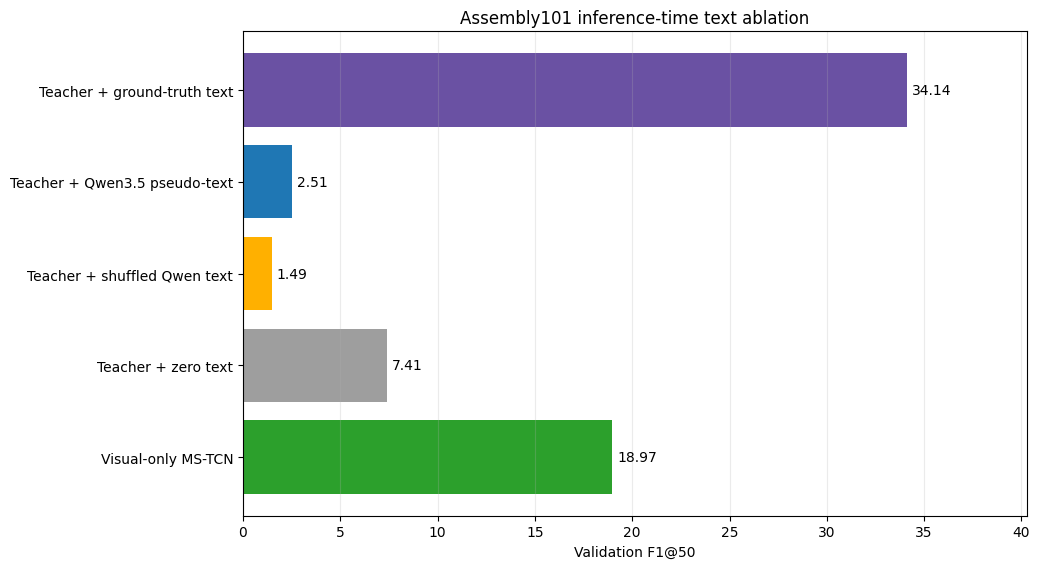

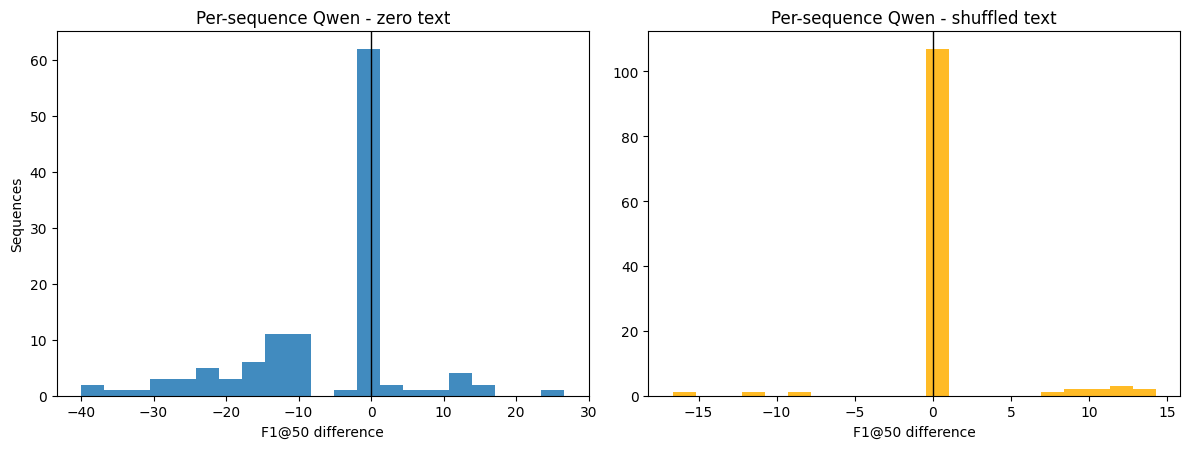

Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/25_qwen_pseudotext_teacher_validation/presentation_artifacts/validation_f1_at_50.png
Saved: /content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/25_qwen_pseudotext_teacher_validation/presentation_artifacts/paired_f1_at_50_differences.png


In [18]:
plot_order = [
    "oracle_gt_text",
    "qwen_pseudotext",
    "shuffled_pseudotext",
    "zero_text",
    "visual_only_mstcn",
]
plot_df = (
    final_metrics_df
    .set_index("variant_key")
    .loc[plot_order]
    .reset_index()
)

colors = ["#6A51A3", "#1F77B4", "#FFB000", "#9E9E9E", "#2CA02C"]
figure, axis = plt.subplots(figsize=(10.5, 5.8))
bars = axis.barh(
    plot_df["variant"],
    plot_df["f1@50"],
    color=colors,
)
axis.invert_yaxis()
axis.set_xlabel("Validation F1@50")
axis.set_title("Assembly101 inference-time text ablation")
axis.grid(axis="x", alpha=0.25)

for bar, value in zip(bars, plot_df["f1@50"]):
    axis.text(
        bar.get_width() + 0.25,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.2f}",
        va="center",
        fontsize=10,
    )

axis.set_xlim(0, max(plot_df["f1@50"]) * 1.18)
figure.tight_layout()
f1_figure_path = ARTIFACT_ROOT / "validation_f1_at_50.png"
figure.savefig(f1_figure_path, dpi=180, bbox_inches="tight")
plt.show()

figure, axes = plt.subplots(1, 2, figsize=(12, 4.6))
axes[0].hist(
    per_sequence_df["qwen_minus_zero_f1@50"],
    bins=21,
    color="#1F77B4",
    alpha=0.85,
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Per-sequence Qwen - zero text")
axes[0].set_xlabel("F1@50 difference")
axes[0].set_ylabel("Sequences")

axes[1].hist(
    per_sequence_df["qwen_minus_shuffled_f1@50"],
    bins=21,
    color="#FFB000",
    alpha=0.85,
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Per-sequence Qwen - shuffled text")
axes[1].set_xlabel("F1@50 difference")

figure.tight_layout()
paired_figure_path = ARTIFACT_ROOT / "paired_f1_at_50_differences.png"
figure.savefig(paired_figure_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:", f1_figure_path)
print("Saved:", paired_figure_path)


## 18. Final summary and next-step lock


In [19]:
final_summary = {
    "status": "completed",
    "task": "Assembly101 Qwen3.5 pseudo-text validation for frozen teacher",
    "primary_metric": "F1@50",
    "data": {
        "split": "validation",
        "num_sequences": len(val_ids),
        "num_temporal_positions": len(val_ids) * EXPECTED_TEMPORAL_LENGTH,
        "test_accessed": False,
    },
    "teacher": {
        "checkpoint": str(TEACHER_CHECKPOINT),
        "checkpoint_epoch": int(teacher_checkpoint["epoch"]),
        "temporal_model": "mstcn",
        "video_representation": "clip_vitb16",
        "parameter_count": int(parameter_count),
        "oracle_reproduction_passed": True,
        "oracle_reproduction_tolerance": ORACLE_REPRO_TOLERANCE,
    },
    "qwen_pseudotext": {
        "model_id": QWEN_MODEL_ID,
        "prompt_sha256": PROMPT_HASH,
        "embedding_root": str(PSEUDOTEXT_DIR),
        "zero_fallback_positions": int(
            pseudo_label_summary["zero_fallback_positions"]
        ),
        "pseudo_label_diagnostics": pseudo_label_summary,
    },
    "validation_metrics": {
        row["variant_key"]: {
            metric_name: float(row[metric_name])
            for metric_name in ["acc", "edit", "f1@10", "f1@25", "f1@50"]
        }
        for _, row in final_metrics_df.iterrows()
    },
    "paired_summary": paired_summary,
    "decision": decision,
    "selection_policy": (
        "Generate test pseudo-text only if Qwen validation F1@50 "
        "beats zero text and shuffled text and is not below the "
        "visual-only MS-TCN validation F1@50."
    ),
    "next_step": (
        "Freeze the current Qwen prompt and generate separate test "
        "pseudo-text once, then evaluate the same teacher once."
        if decision["promote_to_test"]
        else
        "Do not generate test pseudo-text under the strict criterion; "
        "report the validation result as a negative or inconclusive follow-up."
    ),
    "artifacts": {
        "validation_metrics_csv": str(final_metrics_path),
        "validation_decision_json": str(OUT_ROOT / "validation_decision.json"),
        "pseudo_label_diagnostics_csv": str(
            OUT_ROOT / "pseudo_label_validation_diagnostics.csv"
        ),
        "per_sequence_metrics_csv": str(per_sequence_path),
        "teacher_ablation_markdown": str(teacher_table_path),
        "deployable_comparison_markdown": str(deployable_table_path),
        "f1_at_50_figure": str(f1_figure_path),
        "paired_differences_figure": str(paired_figure_path),
    },
    "created_utc": datetime.now(timezone.utc).isoformat(),
}

final_summary_path = OUT_ROOT / "final_summary.json"
final_summary_path.write_text(
    json.dumps(final_summary, indent=2),
    encoding="utf-8",
)

print(json.dumps(final_summary, indent=2))
print("Saved:", final_summary_path)

del teacher
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


{
  "status": "completed",
  "task": "Assembly101 Qwen3.5 pseudo-text validation for frozen teacher",
  "primary_metric": "F1@50",
  "data": {
    "split": "validation",
    "num_sequences": 120,
    "num_temporal_positions": 1920,
    "test_accessed": false
  },
  "teacher": {
    "checkpoint": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual_features_v1/runs/18_text_assisted_concat_teachers/mstcn/clip_vitb16/full/models/best_teacher.pt",
    "checkpoint_epoch": 120,
    "temporal_model": "mstcn",
    "video_representation": "clip_vitb16",
    "parameter_count": 553384,
    "oracle_reproduction_passed": true,
    "oracle_reproduction_tolerance": 0.02
  },
  "qwen_pseudotext": {
    "model_id": "Qwen/Qwen3.5-2B",
    "prompt_sha256": "08047fb92444d9b043a3894ab2c9f91e516a9e466d02e52f67446ed9551701b6",
    "embedding_root": "/content/drive/MyDrive/mmf_tas_lab_data/text_assisted_tas/assembly101/coarse_mstcn_format/streaming_visual

## Interpretation rules

- If Qwen beats zero text and shuffled text, the generated text carries
  useful class and/or temporal information for the frozen teacher.
- If Qwen also reaches or exceeds the visual-only validation baseline,
  the VLM-assisted inference path is worth one locked test evaluation.
- If Qwen is close to zero or shuffled text, the teacher is not benefiting
  from the pseudo-text in a reliable way.
- The oracle row is not deployable because it directly uses validation
  ground-truth action identities.
- Teacher-only inference time excludes the approximately 71.5 seconds per
  sequence spent by Qwen3.5 in Notebook 24; deployment cost must report both.
